使用双接触点控制单特征点的运动

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

---
learning_rate=1.e1; Desired movement=[0.01, 0.01]

In [41]:
num:int = 1
left_ur_data = pd.read_csv(f'left_robot_data{num}.csv')
right_ur_data = pd.read_csv(f'right_robot_data{num}.csv')

# 获取并输出列标题
column_titles = left_ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
strain_sum_np = np.loadtxt(f'strain_sum_list{num}.csv', delimiter=',')
final_strain_np = np.loadtxt(f'final_strain_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = left_ur_data['timestamp'].to_numpy()
time -= time[0]

left_rob_pose_x = left_ur_data['actual_TCP_pose_0'].to_numpy()
left_rob_pose_y = left_ur_data['actual_TCP_pose_1'].to_numpy()

right_rob_pose_x = right_ur_data['actual_TCP_pose_0'].to_numpy()
right_rob_pose_y = right_ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


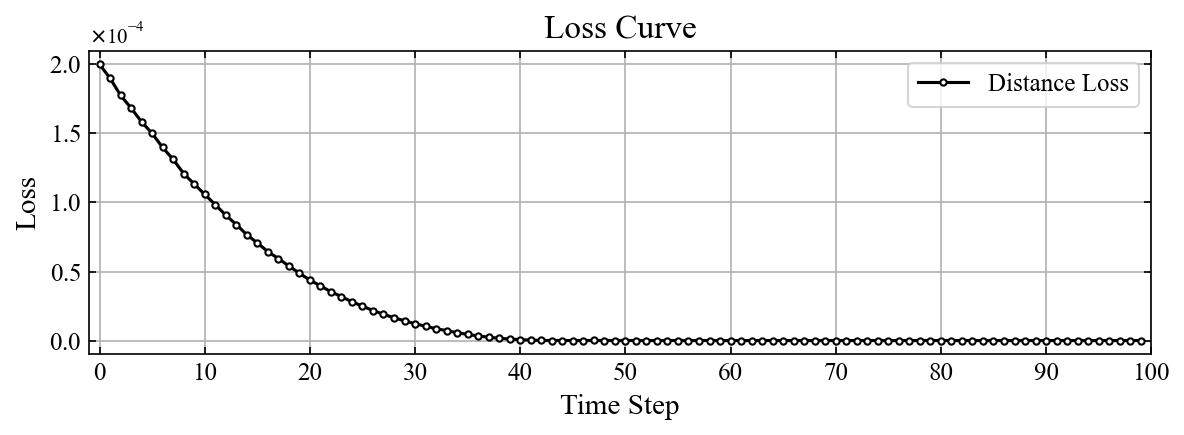

In [12]:
step_num = loss_np.shape[0]
plot_step_num = 100

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Distance Loss', zorder=3)
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

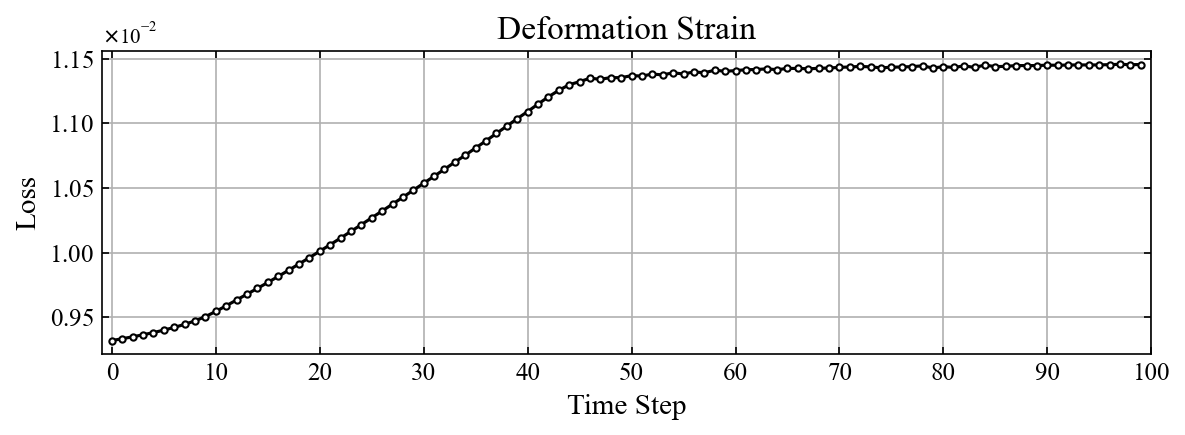

In [15]:
step_num = loss_np.shape[0]
plot_step_num = 100

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(strain_sum_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Deformation Strain', zorder=3)
axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

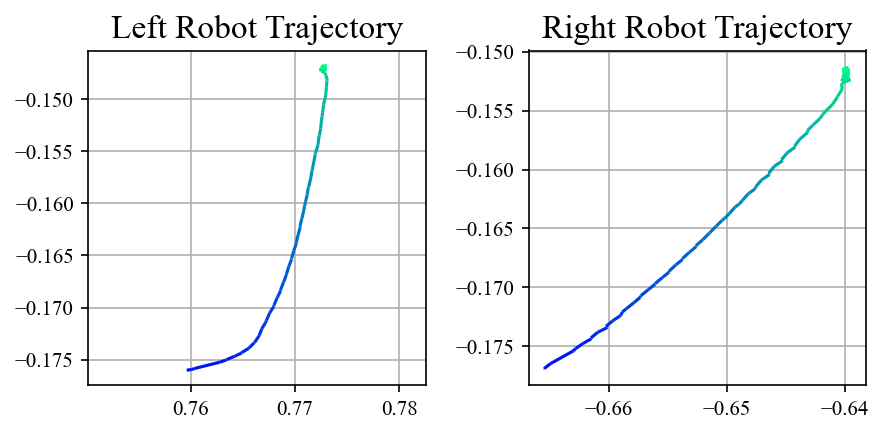

In [45]:
fig_rob = plt.figure(figsize=(6, 3), dpi=150)
gs = GridSpec(1, 2, figure=fig_rob)

plot_step_num = 80
indices_left = np.linspace(0, len(left_rob_pose_x)-1, step_num, dtype=int)
indices_right = np.linspace(0, len(right_rob_pose_x)-1, step_num, dtype=int)
rows = np.arange(plot_step_num)
norm = plt.Normalize(rows.min(), rows.max())
colors = plt.cm.winter(norm(rows))

left_pose = np.stack((left_rob_pose_x[indices_left[:plot_step_num]], left_rob_pose_y[indices_left[:plot_step_num]]), axis=-1).reshape(-1, 1, 2)
segments_left = np.concatenate([left_pose[:-1], left_pose[1:]], axis=1)
lc_left = LineCollection(segments_left, colors=colors, norm=norm)

right_pose = np.stack((right_rob_pose_x[indices_right[:plot_step_num]], right_rob_pose_y[indices_right[:plot_step_num]]), axis=-1).reshape(-1, 1, 2)
segments_right = np.concatenate([right_pose[:-1], right_pose[1:]], axis=1)
lc_right = LineCollection(segments_right, colors=colors, norm=norm)

axs_left = fig_rob.add_subplot(gs[:, 0])
axs_left.add_collection(lc_left)
axs_left.autoscale()
axs_left.set_aspect('equal', 'datalim')
axs_left.set_title('Left Robot Trajectory', fontsize=16)
axs_left.grid(True)

axs_right = fig_rob.add_subplot(gs[:, 1])
axs_right.add_collection(lc_right)
axs_right.autoscale()
axs_right.set_aspect('equal', 'datalim')
axs_right.set_title('Right Robot Trajectory', fontsize=16, fontname='Times New Roman')
axs_right.grid(True)

fig_rob.tight_layout()

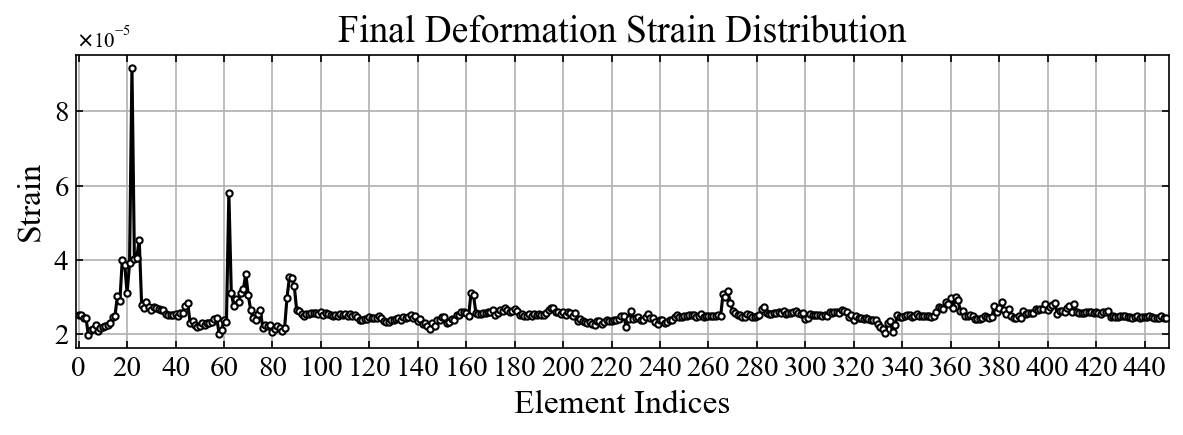

In [42]:
fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_strain_final = fig.add_subplot(gs[0, :])
axs_strain_final.plot(final_strain_np, marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Final Deformation Strain', zorder=3)
axs_strain_final.set_title('Final Deformation Strain Distribution', fontsize=18, fontname='Times New Roman')
axs_strain_final.set_xlabel('Element Indices', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_ylabel('Strain', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_xlim([-1, final_strain_np.shape[0]])
axs_strain_final.xaxis.set_major_locator(MultipleLocator(20))
axs_strain_final.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_strain_final.tick_params(axis='both', labelsize=14, direction='in', top=True, right=True)
axs_strain_final.grid(True, zorder=1)

fig.tight_layout()

---
只使用Left robot控制单特征点运动

learning_rate=5.e0; Desired movement=[0.01, 0.01]

In [36]:
num:int = 2
left_ur_data = pd.read_csv(f'left_robot_data{num}.csv')

# 获取并输出列标题
column_titles = left_ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
strain_sum_np = np.loadtxt(f'strain_sum_list{num}.csv', delimiter=',')
final_strain_np = np.loadtxt(f'final_strain_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = left_ur_data['timestamp'].to_numpy()
time -= time[0]

left_rob_pose_x = left_ur_data['actual_TCP_pose_0'].to_numpy()
left_rob_pose_y = left_ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


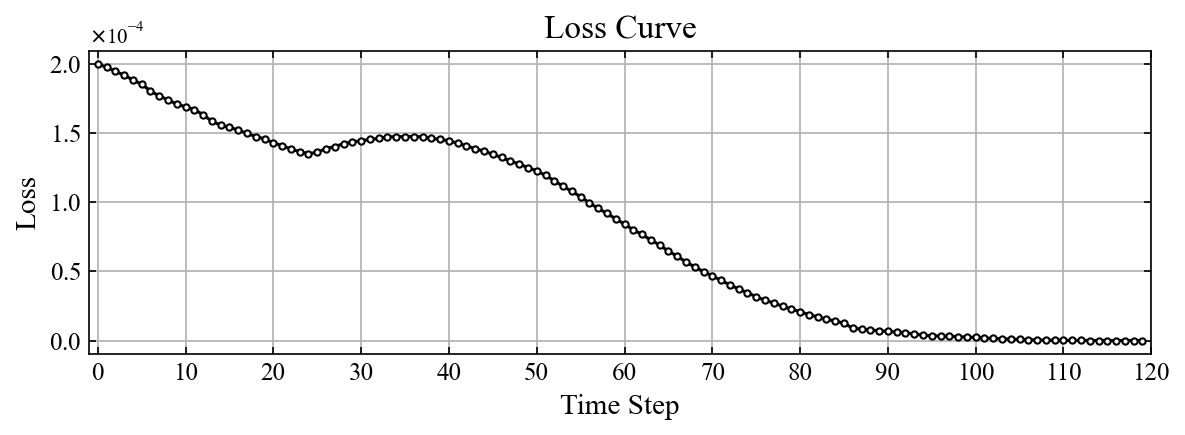

In [32]:
step_num = loss_np.shape[0]
plot_step_num = 120

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Distance Loss', zorder=3)
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

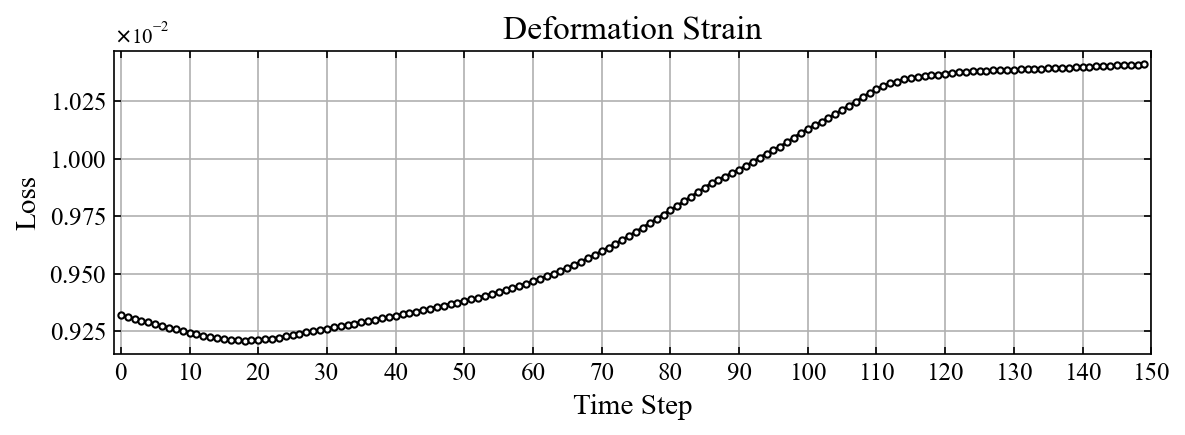

In [35]:
step_num = loss_np.shape[0]
plot_step_num = 150

fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(strain_sum_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Deformation Strain', zorder=3)
axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

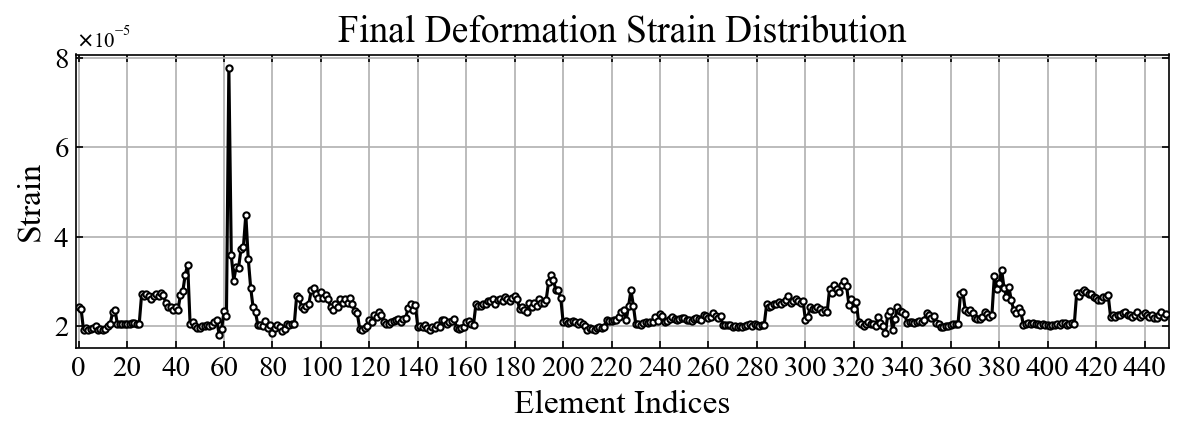

In [40]:
fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_strain_final = fig.add_subplot(gs[0, :])
axs_strain_final.plot(final_strain_np, marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Final Deformation Strain', zorder=3)
axs_strain_final.set_title('Final Deformation Strain Distribution', fontsize=18, fontname='Times New Roman')
axs_strain_final.set_xlabel('Element Indices', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_ylabel('Strain', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_xlim([-1, final_strain_np.shape[0]])
axs_strain_final.xaxis.set_major_locator(MultipleLocator(20))
axs_strain_final.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_strain_final.tick_params(axis='both', labelsize=14, direction='in', top=True, right=True)
axs_strain_final.grid(True, zorder=1)

fig.tight_layout()

---
desired marker+=[0.01, 0]；一个角点和一个边的点（靠近中点）[14, 134]

In [7]:
num:int = 3
left_ur_data = pd.read_csv(f'left_robot_data{num}.csv')

# 获取并输出列标题
column_titles = left_ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
strain_sum_np = np.loadtxt(f'strain_sum_list{num}.csv', delimiter=',')
final_strain_np = np.loadtxt(f'final_strain_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = left_ur_data['timestamp'].to_numpy()
time -= time[0]

left_rob_pose_x = left_ur_data['actual_TCP_pose_0'].to_numpy()
left_rob_pose_y = left_ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


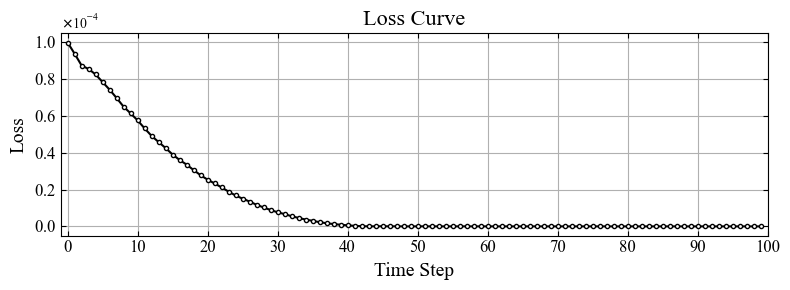

In [8]:
step_num = loss_np.shape[0]
plot_step_num = 100

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Distance Loss', zorder=3)
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

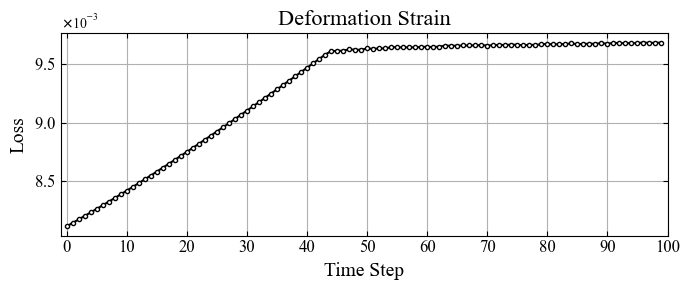

In [9]:
step_num = loss_np.shape[0]
plot_step_num = 100

fig = plt.figure(figsize=(7, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(strain_sum_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Deformation Strain', zorder=3)
axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

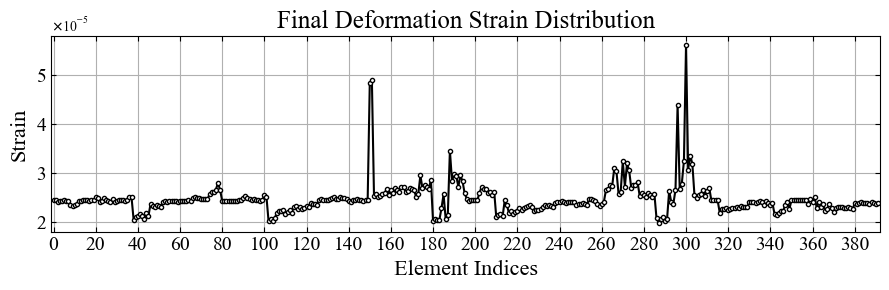

In [10]:
fig = plt.figure(figsize=(9, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_strain_final = fig.add_subplot(gs[0, :])
axs_strain_final.plot(final_strain_np, marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Final Deformation Strain', zorder=3)
axs_strain_final.set_title('Final Deformation Strain Distribution', fontsize=18, fontname='Times New Roman')
axs_strain_final.set_xlabel('Element Indices', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_ylabel('Strain', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_xlim([-1, final_strain_np.shape[0]])
axs_strain_final.xaxis.set_major_locator(MultipleLocator(20))
axs_strain_final.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_strain_final.tick_params(axis='both', labelsize=14, direction='in', top=True, right=True)
axs_strain_final.grid(True, zorder=1)

fig.tight_layout()

---
desired pos+=[0.01, 0]; 两个角点[14, 224]

In [11]:
num:int = 4
left_ur_data = pd.read_csv(f'left_robot_data{num}.csv')

# 获取并输出列标题
column_titles = left_ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
strain_sum_np = np.loadtxt(f'strain_sum_list{num}.csv', delimiter=',')
final_strain_np = np.loadtxt(f'final_strain_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = left_ur_data['timestamp'].to_numpy()
time -= time[0]

left_rob_pose_x = left_ur_data['actual_TCP_pose_0'].to_numpy()
left_rob_pose_y = left_ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


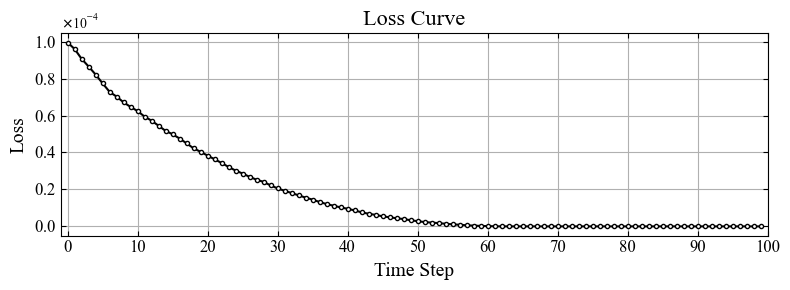

In [12]:
step_num = loss_np.shape[0]
plot_step_num = 100

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Distance Loss', zorder=3)
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

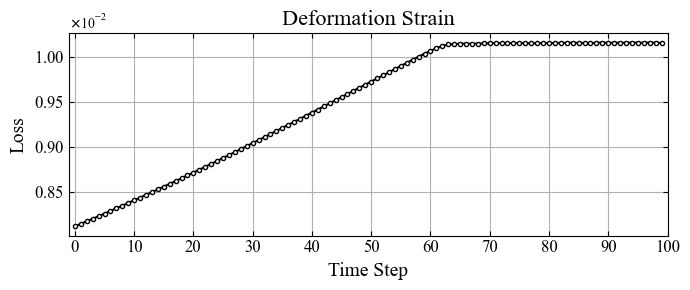

In [13]:
step_num = loss_np.shape[0]
plot_step_num = 100

fig = plt.figure(figsize=(7, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(strain_sum_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Deformation Strain', zorder=3)
axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

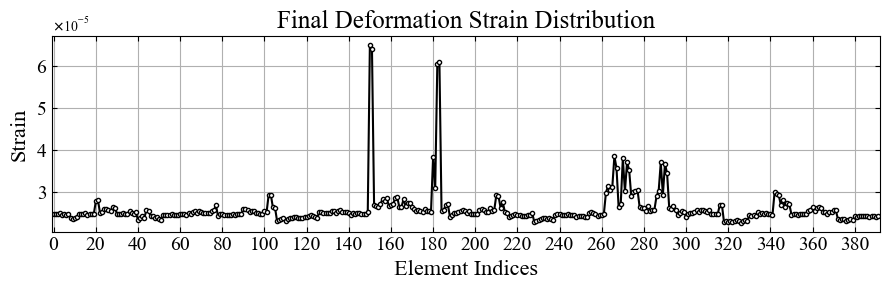

In [14]:
fig = plt.figure(figsize=(9, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_strain_final = fig.add_subplot(gs[0, :])
axs_strain_final.plot(final_strain_np, marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Final Deformation Strain', zorder=3)
axs_strain_final.set_title('Final Deformation Strain Distribution', fontsize=18, fontname='Times New Roman')
axs_strain_final.set_xlabel('Element Indices', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_ylabel('Strain', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_xlim([-1, final_strain_np.shape[0]])
axs_strain_final.xaxis.set_major_locator(MultipleLocator(20))
axs_strain_final.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_strain_final.tick_params(axis='both', labelsize=14, direction='in', top=True, right=True)
axs_strain_final.grid(True, zorder=1)

fig.tight_layout()

---
desired pos+=[0.01, 0]; 两条边上的点[8, 134]

In [3]:
num:int = 5
left_ur_data = pd.read_csv(f'left_robot_data{num}.csv')

# 获取并输出列标题
column_titles = left_ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
strain_sum_np = np.loadtxt(f'strain_sum_list{num}.csv', delimiter=',')
final_strain_np = np.loadtxt(f'final_strain_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = left_ur_data['timestamp'].to_numpy()
time -= time[0]

left_rob_pose_x = left_ur_data['actual_TCP_pose_0'].to_numpy()
left_rob_pose_y = left_ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


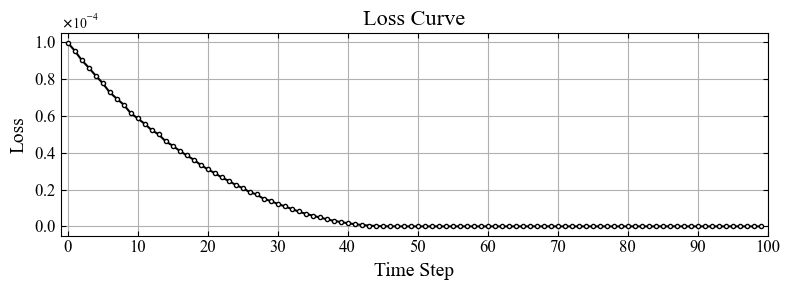

In [4]:
step_num = loss_np.shape[0]
plot_step_num = 100

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Distance Loss', zorder=3)
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

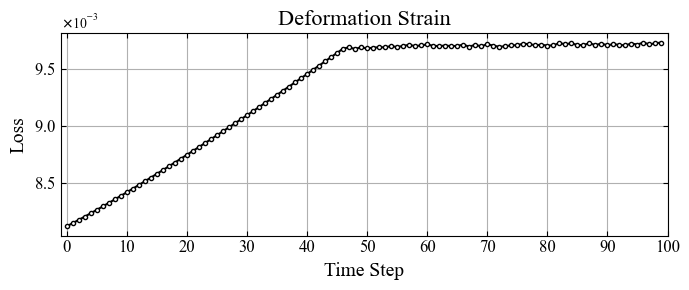

In [5]:
step_num = loss_np.shape[0]
plot_step_num = 100

fig = plt.figure(figsize=(7, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(strain_sum_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Deformation Strain', zorder=3)
axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

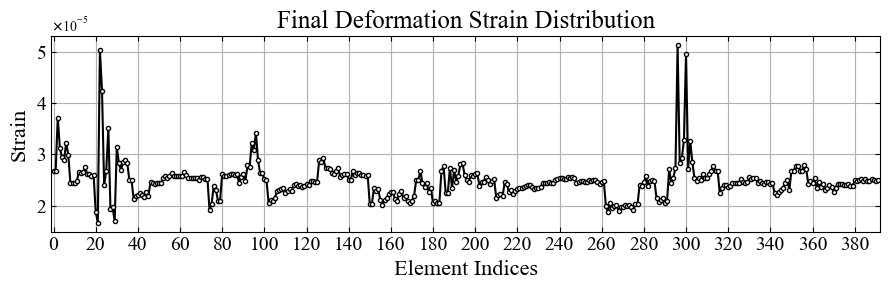

In [6]:
fig = plt.figure(figsize=(9, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_strain_final = fig.add_subplot(gs[0, :])
axs_strain_final.plot(final_strain_np, marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Final Deformation Strain', zorder=3)
axs_strain_final.set_title('Final Deformation Strain Distribution', fontsize=18, fontname='Times New Roman')
axs_strain_final.set_xlabel('Element Indices', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_ylabel('Strain', fontsize=16, fontname='Times New Roman')
axs_strain_final.set_xlim([-1, final_strain_np.shape[0]])
axs_strain_final.xaxis.set_major_locator(MultipleLocator(20))
axs_strain_final.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_strain_final.tick_params(axis='both', labelsize=14, direction='in', top=True, right=True)
axs_strain_final.grid(True, zorder=1)

fig.tight_layout()

---
用于论文绘图

In [2]:
strain_np1 = np.loadtxt(f'strain_sum_list3.csv', delimiter=',')
strain_np2 = np.loadtxt(f'strain_sum_list4.csv', delimiter=',')
strain_np3 = np.loadtxt(f'strain_sum_list5.csv', delimiter=',')
strain_np1 = strain_np1 - strain_np1[0]
strain_np2 = strain_np2 - strain_np2[0]
strain_np3 = strain_np3 - strain_np3[0]

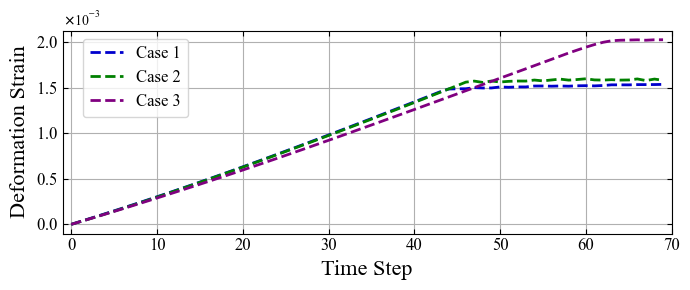

In [13]:
# step_num = loss_np.shape[0]
plot_step_num = 70

fig = plt.figure(figsize=(7, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(strain_np1[:plot_step_num], marker='', markerfacecolor='white', linestyle='--', color='mediumblue', linewidth=2, label=f'Case 1', zorder=3)
axs_loss.plot(strain_np3[:plot_step_num], marker='', markerfacecolor='white', linestyle='--', color='green', linewidth=2, label=f'Case 2', zorder=3)
axs_loss.plot(strain_np2[:plot_step_num], marker='', markerfacecolor='white', linestyle='--', color='purple', linewidth=2, label=f'Case 3', zorder=3)
# axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_loss.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.02, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()
fig.savefig('multi-contact-strain.svg', transparent=True, dpi=300, bbox_inches='tight')

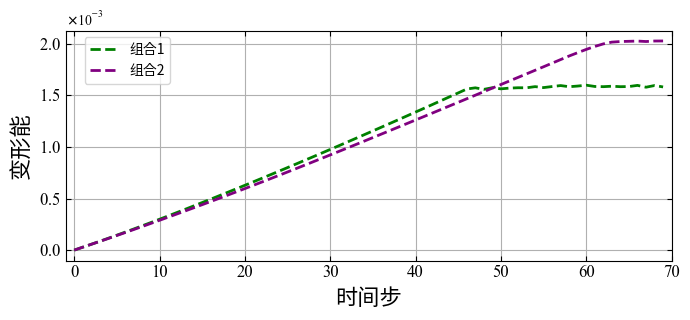

In [7]:
# 设置中文和英文字体路径
# chinese_font_path = "/usr/share/fonts/truetype/arphic/uming.ttc"  # SimSun 替代字体
chinese_font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
english_font_path = "/usr/share/fonts/truetype/msttcorefonts/times.ttf"  # Times New Roman

# 设置字体属性
chinese_font_prop = fm.FontProperties(fname=chinese_font_path)
english_font_prop = fm.FontProperties(fname=english_font_path)

# font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
# font_prop = fm.FontProperties(fname=font_path)

plot_step_num = 70

fig = plt.figure(figsize=(7, 3.3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
# axs_loss.plot(strain_np1[:plot_step_num], marker='', markerfacecolor='white', linestyle='--', color='mediumblue', linewidth=2, label=f'Case 1', zorder=3)
axs_loss.plot(strain_np3[:plot_step_num], marker='', markerfacecolor='white', linestyle='--', color='green', linewidth=2, label=f'组合1', zorder=3)
axs_loss.plot(strain_np2[:plot_step_num], marker='', markerfacecolor='white', linestyle='--', color='purple', linewidth=2, label=f'组合2', zorder=3)
# axs_loss.set_title('Deformation Strain', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('时间步', fontsize=16, fontproperties=chinese_font_prop)
axs_loss.set_ylabel('变形能', fontsize=16, fontproperties=chinese_font_prop)
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_loss.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.02, 1), bbox_transform=axs_loss.transAxes, prop=chinese_font_prop)
axs_loss.grid(True, zorder=1)

fig.tight_layout()
fig.savefig('multi-contact-strain-chinese.svg', transparent=True, dpi=300, bbox_inches='tight')